In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from concurrent.futures import ThreadPoolExecutor
from datetime import date

import cma
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import (
    kge,
    kge_alpha,
    kge_beta,
    kge_r,
    mkge,
    mkge_alpha,
    nse,
)
from aquacrop_slovenia.parameters_running_rakican import (
    rakican_curve_number,
    rakican_groundwater,
    rakican_initial_cond,
    rakican_maize_params,
    rakican_management,
    rakican_readily_evaporable_water,
    rakican_soil_layers,
)
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison
from aquacrop_slovenia.reading_data import (
    get_co2_for_aquacrop,
    get_station_weather,
    get_yield,
    get_yield_for_comparison,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "rakican"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 4, 20),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [1998, 2023, 2017]
]

temperatures, eto, rain = get_station_weather(355)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil",
    soil_layers=rakican_soil_layers,
    curve_number=rakican_curve_number,
    readily_evaporable_water=rakican_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in rakican_maize_params.items() if isinstance(val, int)}

In [4]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.MODEL_RUNNING_DIR / f"calibration_rakican_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories ready: {MAX_WORKERS}")

Worker directories ready: 28


## Calibrating for biomass

In [5]:
# Parameter names, search bounds, and initial guess (midpoint of bounds)
param_names = [
    #"harvest_index",
    "gdd_emergence",
    "gdd_max_rooting",
    "gdd_senescence",
    "gdd_maturity",
    "gdd_flowering",
    "gdd_flowering_length",
    #"gdd_hi_start",
    "max_canopy_cover",
    #"cgc_gdd",
    #"cdc_gdd",
    #"min_rooting_depth",
    "max_rooting_depth",
    #"p_upper_senescence",
    #"p_upper_stomata"
]

bounds = [
    #(0.46, 0.6),    # harvest_index
    (5, 100),        # gdd_emergence
    (800, 1200),    # gdd_max_rooting
    (800, 1200),    # gdd_senescence
    (800, 1200),    # gdd_maturity
    (350,  550),    # gdd_flowering
    (80,  170),    # gdd_flowering_length
    #(300, 500),     # gdd_hi_start
    (0.85, 0.97),   # max_canopy_cover
    #(0.005, 0.03),  # cgc_gdd
    #(0.005, 0.02),  # cdc_gdd
    #(0.1, 0.4),    # min_rooting_depth
    (0.5, 2.5),     # max_rooting_depth
    #(0.4, 0.8),     # p_upper_senescence
    #(0.4, 0.8),     # p_upper_stomata
]

lower = np.array([b[0] for b in bounds])
upper = np.array([b[1] for b in bounds])
x0 = (lower + upper) / 2.0

print(f"Parameters: {param_names}")
print(f"x0:         {x0}")
print(f"Bounds:     {bounds}")

Parameters: ['gdd_emergence', 'gdd_max_rooting', 'gdd_senescence', 'gdd_maturity', 'gdd_flowering', 'gdd_flowering_length', 'max_canopy_cover', 'max_rooting_depth']
x0:         [5.25e+01 1.00e+03 1.00e+03 1.00e+03 4.50e+02 1.25e+02 9.10e-01 1.50e+00]
Bounds:     [(5, 100), (800, 1200), (800, 1200), (800, 1200), (350, 550), (80, 170), (0.85, 0.97), (0.5, 2.5)]


In [6]:
def evaluate_params(param_values, base_params=rakican_maize_params):
    """Run one candidate and return all metrics for both grain and biomass.

    `base_params` is the parameter dict `param_names`/`param_values` are applied
    on top of; defaults to the parameters from parameters_running_rakican.py.
    """
    working_dir = dir_queue.get()
    try:
        crop_params = copy.deepcopy(base_params)

        for name, val in zip(param_names, param_values):
            crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="cma-es",
            params=crop_params,
        )

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=soil,
            management=rakican_management,
            initial_conditions=rakican_initial_cond,
            climate=weather,
            ground_water=rakican_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_metrics = {
            f"{prefix}_{s}": np.nan
            for prefix in ("biomass", "grain")
            for s in ["rmse", "r2", "nse", "kge", "mkge", "kge_r", "kge_beta", "kge_alpha", "mkge_alpha"]
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return nan_metrics

        seasonal = results["season"][["Year1", "BioMass", "Y(dry)"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled", "Y(dry)": "grain_modeled"}
        )

        def compute_metrics(observed_df, modeled_col, prefix):
            # dropna: some years are missing an observed value (e.g. Rakican has no
            # biomass measurement for 2020/2021) — skip those rather than feeding
            # NaN into the metrics.
            merged = observed_df.merge(seasonal[["year", modeled_col]], on="year").dropna(
                subset=["yield", modeled_col]
            )
            y_obs = merged["yield"].values
            y_mod = merged[modeled_col].values
            return {
                f"{prefix}_rmse":       root_mean_squared_error(y_obs, y_mod),
                f"{prefix}_nse":        nse(y_mod, y_obs),
                f"{prefix}_kge":        kge(y_mod, y_obs),
                f"{prefix}_mkge":       mkge(y_mod, y_obs),
                f"{prefix}_kge_r":      kge_r(y_mod, y_obs),
                f"{prefix}_kge_beta":   kge_beta(y_mod, y_obs),
                f"{prefix}_kge_alpha":  kge_alpha(y_mod, y_obs),
                f"{prefix}_mkge_alpha": mkge_alpha(y_mod, y_obs),
            }

        return {
            **compute_metrics(observed_biomass, "biomass_modeled", "biomass"),
            **compute_metrics(observed_grain,   "grain_modeled",   "grain"),
        }
    finally:
        dir_queue.put(working_dir)

In [7]:
eval_log = []           # collects every evaluated candidate for post-analysis
eval_log_lock = threading.Lock()
convergence_logs = {}   # objective_name -> [(iteration, fbest), ...]

mean_biomass = observed_biomass["yield"].mean()
mean_grain   = observed_grain["yield"].mean()
print(f"Mean observed biomass: {mean_biomass:.1f}  |  mean observed grain: {mean_grain:.1f}")


def make_objective(scalar_fn):
    """Return a function that evaluates one candidate, logs it, and returns a scalar."""
    def objective(param_values):
        r = evaluate_params(param_values)
        with eval_log_lock:
            eval_log.append({**dict(zip(param_names, param_values)), **r})
        return scalar_fn(r)
    return objective


objectives = {
    "biomass_rmse":   make_objective(lambda r: r["biomass_rmse"]),
    "biomass_mkge":   make_objective(lambda r: -r["biomass_mkge"]),   # negate: CMA-ES minimises
    "grain_rmse":     make_objective(lambda r: r["grain_rmse"]),
    "grain_mkge":     make_objective(lambda r: -r["grain_mkge"]),     # negate: CMA-ES minimises
    "combined_nrmse": make_objective(
        lambda r: r["biomass_rmse"] / mean_biomass + r["grain_rmse"] / mean_grain
    ),
}

Mean observed biomass: 14.9  |  mean observed grain: 7.7


In [8]:
# CMA-ES settings
SIGMA0 = 0.02

CMAES_OPTIONS = {
    "bounds": [lower.tolist(), upper.tolist()],
    "CMA_stds": (upper - lower).tolist(),  # scale sigma0 per-coordinate to each param's own range
    "popsize": MAX_WORKERS,
    "maxiter": 20,
    "tolx": 1e-5,
    "tolfun": 1e-5,
    "seed": 10,
    "verbose": 3,
}

print(f"Cores: {MAX_WORKERS}")
print(f"Options: {CMAES_OPTIONS}")

Cores: 28
Options: {'bounds': [[5.0, 800.0, 800.0, 800.0, 350.0, 80.0, 0.85, 0.5], [100.0, 1200.0, 1200.0, 1200.0, 550.0, 170.0, 0.97, 2.5]], 'CMA_stds': [95.0, 400.0, 400.0, 400.0, 200.0, 90.0, 0.12, 2.0], 'popsize': 28, 'maxiter': 20, 'tolx': 1e-05, 'tolfun': 1e-05, 'seed': 10, 'verbose': 3}


In [9]:
def parallel_evaluate(objective_fn, solutions):
    """Evaluate a list of candidate solutions in parallel using ThreadPoolExecutor."""
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        return list(executor.map(objective_fn, solutions))

In [10]:
def run_cmaes(objective_name):
    """Run CMA-ES for a given objective and return the CMAEvolutionStrategy object."""
    objective_fn = objectives[objective_name]
    es = cma.CMAEvolutionStrategy(x0, SIGMA0, CMAES_OPTIONS)
    convergence_logs[objective_name] = []

    while not es.stop():
        solutions = es.ask()
        fitnesses = parallel_evaluate(objective_fn, solutions)
        penalty = max((f for f in fitnesses if np.isfinite(f)), default=1e6) * 10
        fitnesses = [penalty if not np.isfinite(f) else f for f in fitnesses]
        es.tell(solutions, fitnesses)
        es.disp()
        convergence_logs[objective_name].append((es.result.iterations, es.result.fbest))

    es.result_pretty()
    return es

In [11]:
eval_log.clear()
print("=== Optimising for BIOMASS RMSE ===")
es_biomass_rmse = run_cmaes("biomass_rmse")
print(f"\nBest biomass RMSE: {es_biomass_rmse.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_biomass_rmse.result.xbest):
    print(f"  {name}: {val:.4f}")

biomass_best_params = dict(zip(param_names, es_biomass_rmse.result.xbest))

=== Optimising for BIOMASS RMSE ===
(14_w,28)-aCMA-ES (mu_w=8.1,w_1=21%) in dimension 8 (seed=10, Fri Sep  4 14:09:07 2026)
Results successfully parsedResults successfully parsed



## Evaluation

In [12]:
# Re-evaluate each best solution to get the full metric set
cmaes_runs = {
    "biomass_rmse":   es_biomass_rmse.result.xbest,
    #"biomass_mkge":   es_biomass_mkge.result.xbest,
    #"grain_rmse":     es_grain.result.xbest,
    #"grain_mkge":     es_grain_mkge.result.xbest,
    #"combined_nrmse": es_combined.result.xbest,
}

summary_rows = []
for run_name, x in cmaes_runs.items():
    metrics = evaluate_params(x)
    row = {"optimised_for": run_name, **dict(zip(param_names, x)), **metrics}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("optimised_for")
summary_df

,gdd_emergence,gdd_max_rooting,gdd_senescence,gdd_maturity,gdd_flowering,gdd_flowering_length,max_canopy_cover,max_rooting_depth,biomass_rmse,biomass_nse,...,biomass_kge_alpha,biomass_mkge_alpha,grain_rmse,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
optimised_for,,,,,,,,,,,,,,,,,,,,,
biomass_rmse,35.411126,1084.402571,994.450042,981.31104,488.811086,143.324297,0.911161,0.527767,2.666775,0.474254,...,0.515103,0.533125,1.821519,0.316356,0.365269,0.397893,0.647967,0.922426,0.477564,0.517726


In [13]:
display_cols = [
    "biomass_rmse", "biomass_nse", "biomass_kge", "biomass_mkge",
    "grain_rmse", "grain_nse",   "grain_kge",   "grain_mkge",
]
print("Metric comparison across optimisation targets:")
summary_df[display_cols].round(3)

,biomass_rmse,biomass_nse,biomass_kge,biomass_mkge,grain_rmse,grain_nse,grain_kge,grain_mkge
optimised_for,,,,,,,,
biomass_rmse,2.667,0.474,0.447,0.463,1.822,0.316,0.365,0.398


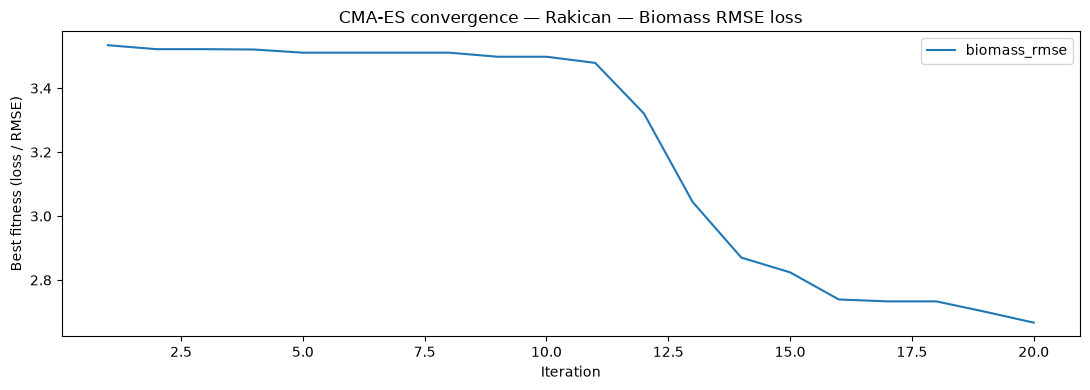

In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4))

for obj_name, log in convergence_logs.items():
    iters, fbest = zip(*log)
    values = [f for f in fbest]
    ax.plot(iters, values, label=obj_name)

#ax.semilogy()
ax.set_xlabel("Iteration")
ax.set_ylabel("Best fitness (loss / RMSE)")
ax.set_title("CMA-ES convergence — Rakican — Biomass RMSE loss")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# All evaluated candidates from the last CMA-ES run (combined)
all_evals_df = pd.DataFrame(eval_log)
print(f"Total evaluations stored from last run: {len(all_evals_df)}")
all_evals_df.sort_values("biomass_rmse")

,gdd_emergence,gdd_max_rooting,gdd_senescence,gdd_maturity,gdd_flowering,gdd_flowering_length,max_canopy_cover,max_rooting_depth,biomass_rmse,biomass_nse,...,biomass_kge_alpha,biomass_mkge_alpha,grain_rmse,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
534,35.411126,1084.402571,994.450042,981.311040,488.811086,143.324297,0.911161,0.527767,2.666775,0.474254,...,0.515103,0.533125,1.821519,0.316356,0.365269,0.397893,0.647967,0.922426,0.477564,0.517726
514,59.554442,979.569631,926.393521,1023.103990,517.624618,148.800523,0.899959,0.505756,2.700895,0.460715,...,0.529028,0.536889,1.783071,0.344912,0.356022,0.379466,0.648168,0.942307,0.463723,0.492114
556,66.169527,992.684061,967.071584,1006.772516,526.889229,135.493251,0.927143,0.554158,2.723784,0.451536,...,0.492877,0.497025,1.805158,0.328582,0.322621,0.342274,0.634754,0.948224,0.431883,0.455465
467,56.023385,969.520283,951.933326,1008.506665,495.196927,153.233820,0.908355,0.500816,2.733234,0.447724,...,0.513048,0.533133,1.830100,0.309900,0.348423,0.380720,0.653583,0.920929,0.453835,0.492802
474,66.852119,992.341390,1008.056449,1038.932167,499.513061,124.313867,0.915279,0.502461,2.736064,0.446579,...,0.532490,0.550869,1.828522,0.311090,0.350146,0.381576,0.647768,0.923196,0.459312,0.497524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,69.228106,890.874009,967.940482,1017.896785,492.964978,150.636899,0.917302,1.002890,3.603442,0.040073,...,0.156751,0.147564,2.163354,0.035688,-0.164050,-0.166177,0.220331,1.021517,0.135902,0.133039
24,55.647762,1005.343150,998.160404,990.963421,447.440086,125.564913,0.907058,1.491128,3.608238,0.037517,...,0.113091,0.117297,2.205896,-0.002611,-0.088253,-0.078572,0.333593,0.920767,0.143309,0.155641
16,51.411085,989.436354,1009.889766,1019.722970,455.533067,125.623239,0.912454,1.506673,3.636513,0.022373,...,0.127018,0.121544,2.135051,0.060755,-0.114351,-0.114177,0.273642,0.998516,0.154908,0.155138
557,28.386928,933.092159,971.008372,1008.018232,455.758019,139.842935,0.898531,0.946673,3.638273,0.021426,...,0.187445,0.172099,2.114202,0.079009,-0.025318,-0.032052,0.354068,1.044149,0.204953,0.196287


In [16]:
list(zip(param_names, es_biomass_rmse.result.xbest))

[('gdd_emergence', np.float64(35.41112582329015)),
 ('gdd_max_rooting', np.float64(1084.402571133931)),
 ('gdd_senescence', np.float64(994.4500418357326)),
 ('gdd_maturity', np.float64(981.3110399358051)),
 ('gdd_flowering', np.float64(488.8110857130533)),
 ('gdd_flowering_length', np.float64(143.32429736204364)),
 ('max_canopy_cover', np.float64(0.911161418027634)),
 ('max_rooting_depth', np.float64(0.5277668322584468))]

In [17]:
output_path = config.RESULTS_DIR / "cmaes_rakican_calibration_rmse_params_1.pkl"
summary_df.reset_index().to_pickle(output_path)
print(f"Saved summary ({len(summary_df)} rows) to {output_path}")

In [18]:
def rerun_best(param_values, label, base_params=rakican_maize_params):
    """Re-run a full simulation with given params and return seasonal results."""
    params = copy.deepcopy(base_params)
    for name, val in zip(param_names, param_values):
        params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

    best_dir = config.MODEL_RUNNING_DIR / f"cmaes_rakican_best_{label}"
    best_dir.mkdir(parents=True, exist_ok=True)

    sim = AquaCrop(
        simulation_periods=simulation_periods,
        crop=Crop(name=f"{LOCATION} maize ({label})", description=label, params=params),
        soil=soil,
        management=rakican_management,
        initial_conditions=rakican_initial_cond,
        climate=weather,
        ground_water=rakican_groundwater,
        working_dir=best_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )
    return sim.run()["season"]

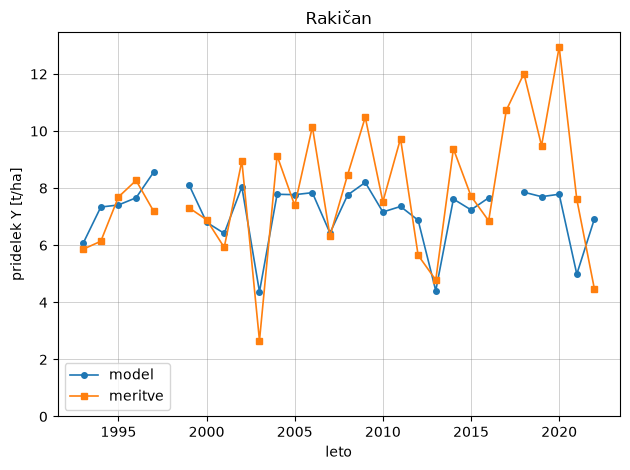

In [19]:
seasonal_biomass_rmse_opt = rerun_best(es_biomass_rmse.result.xbest, "biomass_rmse_opt")
print("=== Best solution optimised for biomass rmse ===")
plot_yield_timeseries_comparison(seasonal_biomass_rmse_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)

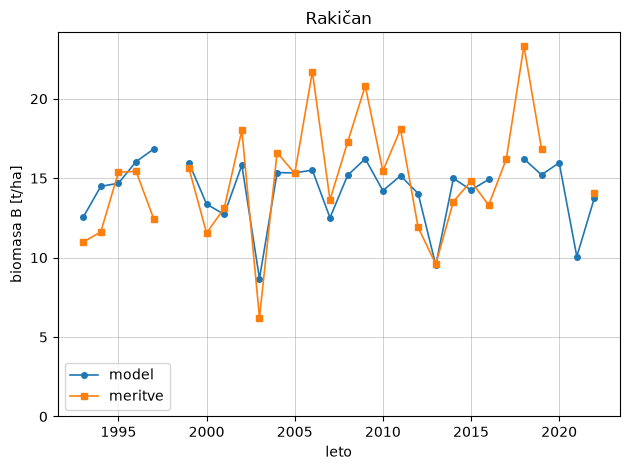

In [20]:
plot_yield_timeseries_comparison(seasonal_biomass_rmse_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass", LOCATION)

## Calibrate for yield

Rather than hand-editing `parameters_running_rakican.py`, the biomass-calibrated
values (`es_biomass_rmse.result.xbest`) are applied programmatically on top of
`rakican_maize_params` below. The yield calibration below then optimises
`harvest_index`/`gdd_hi_start` starting from this biomass-calibrated parameter set.

In [21]:
rakican_maize_params_biomass_calibrated = copy.deepcopy(rakican_maize_params)
for name, val in biomass_best_params.items():
    rakican_maize_params_biomass_calibrated[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

print("Biomass-calibrated base parameters (overrides on top of rakican_maize_params):")
for name, val in biomass_best_params.items():
    print(f"  {name}: {rakican_maize_params_biomass_calibrated[name]}")

In [22]:
param_names = [
    "harvest_index",
    #"gdd_emergence",
    #"gdd_max_rooting",
    #"gdd_senescence",
    #"gdd_maturity",
    #"gdd_flowering",
    #"gdd_flowering_length",
    "gdd_hi_start",
    #"max_canopy_cover",
    #"cgc_gdd",
    #"cdc_gdd",
    #"min_rooting_depth",
    #"max_rooting_depth",
    #"p_upper_senescence",
    #"p_upper_stomata"
]

bounds = [
    (0.46, 0.65),    # harvest_index
    #(5, 40),        # gdd_emergence
    #(700, 1000),    # gdd_max_rooting
    #(700, 1000),    # gdd_senescence
    #(900, 1200),    # gdd_maturity
    #(350,  550),    # gdd_flowering
    #(80,  170),    # gdd_flowering_length
    (300, 500),     # gdd_hi_start
    #(0.85, 0.97),   # max_canopy_cover
    #(0.005, 0.03),  # cgc_gdd
    #(0.005, 0.02),  # cdc_gdd
    #(0.05, 0.4),    # min_rooting_depth
    #(0.5, 2.5),     # max_rooting_depth
    #(0.4, 0.8),     # p_upper_senescence
    #(0.4, 0.8),     # p_upper_stomata
]

lower = np.array([b[0] for b in bounds])
upper = np.array([b[1] for b in bounds])
x0 = (lower + upper) / 2.0

def to_unit(x):
    return (np.asarray(x) - lower) / (upper - lower)

def from_unit(x_norm):
    return lower + np.asarray(x_norm) * (upper - lower)

print(f"Parameters: {param_names}")
print(f"x0:         {x0}")

In [23]:
eval_log = []           # collects every evaluated candidate for post-analysis
eval_log_lock = threading.Lock()
convergence_logs = {}   # objective_name -> [(iteration, fbest), ...]

mean_biomass = observed_biomass["yield"].mean()
mean_grain   = observed_grain["yield"].mean()
print(f"Mean observed biomass: {mean_biomass:.1f}  |  mean observed grain: {mean_grain:.1f}")


def make_objective(scalar_fn, base_params=rakican_maize_params_biomass_calibrated):
    """Return a function that evaluates one candidate, logs it, and returns a scalar.

    Candidates are evaluated on top of `base_params` — here the biomass-calibrated
    parameter set, so the yield search starts from `es_biomass_mkge`'s best solution.
    """
    def objective(param_values):
        r = evaluate_params(param_values, base_params=base_params)
        with eval_log_lock:
            eval_log.append({**dict(zip(param_names, param_values)), **r})
        return scalar_fn(r)
    return objective


objectives = {
    "biomass_rmse":   make_objective(lambda r: r["biomass_rmse"]),
    "biomass_mkge":   make_objective(lambda r: -r["biomass_mkge"]),   # negate: CMA-ES minimises
    "grain_rmse":     make_objective(lambda r: r["grain_rmse"]),
    "grain_mkge":     make_objective(lambda r: -r["grain_mkge"]),     # negate: CMA-ES minimises
    "combined_nrmse": make_objective(
        lambda r: r["biomass_rmse"] / mean_biomass + r["grain_rmse"] / mean_grain
    ),
}

In [24]:
# CMA-ES settings
SIGMA0 = 0.02

CMAES_OPTIONS = {
    "bounds": [lower.tolist(), upper.tolist()],
    "CMA_stds": (upper - lower).tolist(),  # scale sigma0 per-coordinate to each param's own range
    "popsize": MAX_WORKERS,
    "maxiter": 20,
    "tolx": 1e-5,
    "tolfun": 1e-5,
    "seed": 10,
    "verbose": 3,
}

print(f"Cores: {MAX_WORKERS}")
print(f"Options: {CMAES_OPTIONS}")

In [25]:
eval_log.clear()
print("=== Optimising for GRAIN RMSE ===")
es_grain_rmse = run_cmaes("grain_rmse")
print(f"\nBest grain RMSE: {es_grain_rmse.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_grain_rmse.result.xbest):
    print(f"  {name}: {val:.4f}")

## Evaluation

In [26]:
# Re-evaluate both best parameter sets, using the biomass-calibrated set as base:
#  - "biomass_rmse": the biomass-calibrated set as-is (harvest_index/gdd_hi_start
#    left at their rakican_maize_params defaults) — the pre-yield-calibration baseline.
#  - "grain_rmse": the same base with harvest_index/gdd_hi_start replaced by
#    es_grain_rmse's best solution.
baseline_values = np.array([rakican_maize_params_biomass_calibrated[name] for name in param_names])

cmaes_runs = {
    "biomass_rmse": baseline_values,
    "grain_rmse":   es_grain_rmse.result.xbest,
}

summary_rows = []
for run_name, x in cmaes_runs.items():
    metrics = evaluate_params(x, base_params=rakican_maize_params_biomass_calibrated)
    row = {"optimised_for": run_name, **dict(zip(param_names, x)), **metrics}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("optimised_for")
summary_df

,harvest_index,gdd_hi_start,biomass_rmse,biomass_nse,biomass_kge,biomass_mkge,biomass_kge_r,biomass_kge_beta,biomass_kge_alpha,biomass_mkge_alpha,grain_rmse,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
optimised_for,,,,,,,,,,,,,,,,,,
biomass_rmse,0.563000,410.000000,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.821519,0.316356,0.365269,0.397893,0.647967,0.922426,0.477564,0.517726
grain_rmse,0.612481,499.857083,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.694056,0.408687,0.408663,0.407446,0.652713,1.002889,0.521394,0.519892


In [27]:
display_cols = [
    "biomass_rmse", "biomass_nse", "biomass_kge", "biomass_mkge",
    "grain_rmse", "grain_nse",   "grain_kge",   "grain_mkge",
]
print("Metric comparison across optimisation targets:")
summary_df[display_cols].round(3)

,biomass_rmse,biomass_nse,biomass_kge,biomass_mkge,grain_rmse,grain_nse,grain_kge,grain_mkge
optimised_for,,,,,,,,
biomass_rmse,2.667,0.474,0.447,0.463,1.822,0.316,0.365,0.398
grain_rmse,2.667,0.474,0.447,0.463,1.694,0.409,0.409,0.407


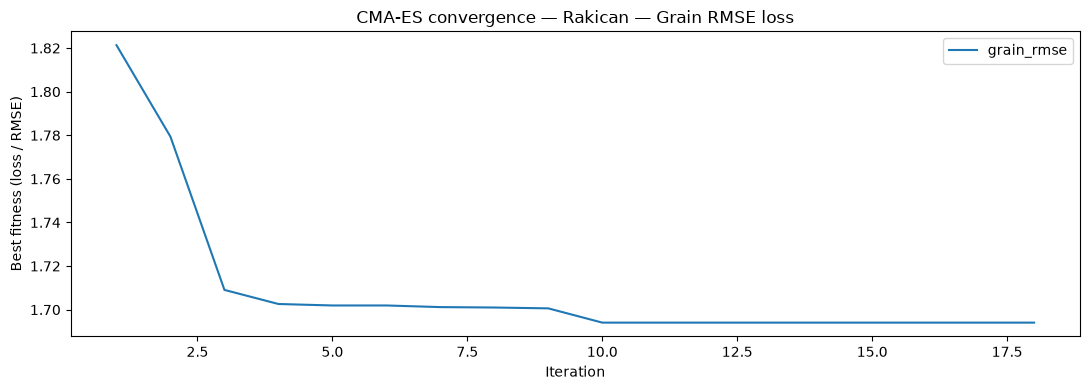

In [28]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4))

for obj_name, log in convergence_logs.items():
    iters, fbest = zip(*log)
    values = [f for f in fbest]
    ax.plot(iters, values, label=obj_name)

#ax.semilogy()
ax.set_xlabel("Iteration")
ax.set_ylabel("Best fitness (loss / RMSE)")
ax.set_title("CMA-ES convergence — Rakican — Grain RMSE loss")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# All evaluated candidates from the last CMA-ES run (combined)
all_evals_df = pd.DataFrame(eval_log)
print(f"Total evaluations stored from last run: {len(all_evals_df)}")
all_evals_df.sort_values("biomass_rmse")

,harvest_index,gdd_hi_start,biomass_rmse,biomass_nse,biomass_kge,biomass_mkge,biomass_kge_r,biomass_kge_beta,biomass_kge_alpha,biomass_mkge_alpha,grain_rmse,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
0,0.560060,402.861187,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.821333,0.316496,0.365173,0.397761,0.648036,0.922496,0.477391,0.517500
1,0.556009,400.434205,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.821450,0.316408,0.365067,0.397625,0.647833,0.922551,0.477392,0.517469
2,0.557509,398.596477,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.821552,0.316332,0.364895,0.397422,0.647707,0.922597,0.477260,0.517301
3,0.553984,397.802709,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.871274,0.278498,0.355717,0.395124,0.647681,0.906149,0.468809,0.517364
4,0.555869,401.780595,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.821333,0.316496,0.365173,0.397761,0.648036,0.922496,0.477391,0.517500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.608250,499.998561,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.694056,0.408687,0.408663,0.407446,0.652713,1.002889,0.521394,0.519892
500,0.612558,499.982480,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.694056,0.408687,0.408663,0.407446,0.652713,1.002889,0.521394,0.519892
501,0.609582,499.878305,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.694056,0.408687,0.408663,0.407446,0.652713,1.002889,0.521394,0.519892
502,0.609679,499.865951,2.666775,0.474254,0.446875,0.462604,0.736031,0.966196,0.515103,0.533125,1.694056,0.408687,0.408663,0.407446,0.652713,1.002889,0.521394,0.519892


In [30]:
list(zip(param_names, es_grain_rmse.result.xbest))

[('harvest_index', np.float64(0.6124813207897354)),
 ('gdd_hi_start', np.float64(499.857083471872))]

In [31]:
output_path = config.RESULTS_DIR / "cmaes_rakican_calibration_rmse_params_2.pkl"
summary_df.reset_index().to_pickle(output_path)
print(f"Saved summary ({len(summary_df)} rows) to {output_path}")

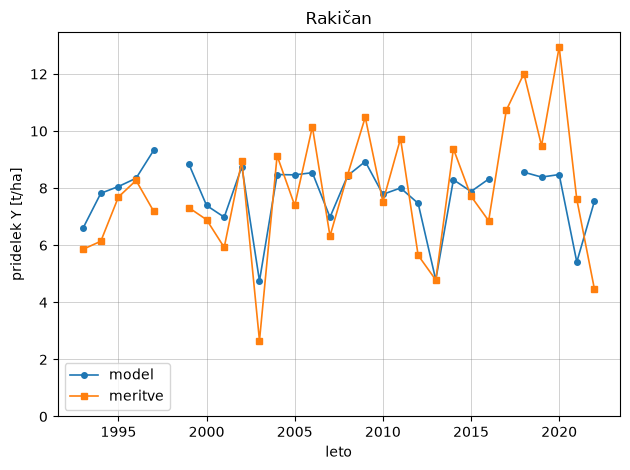

In [32]:
seasonal_grain_rmse_opt = rerun_best(
    es_grain_rmse.result.xbest, "grain_rmse_opt", base_params=rakican_maize_params_biomass_calibrated
)
print("=== Best solution optimised for grain rmse ===")
plot_yield_timeseries_comparison(seasonal_grain_rmse_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)

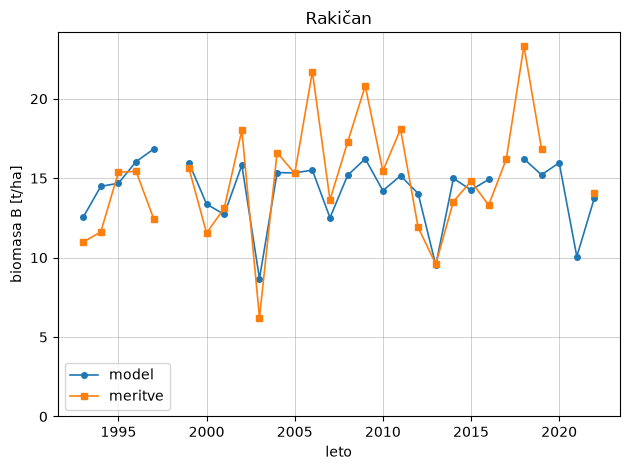

In [33]:
plot_yield_timeseries_comparison(seasonal_grain_rmse_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass", LOCATION)